LOGISTIC REGRESSION vs DECISION TREE - PNEUMONIA DETECTION

📂 Loading dataset...
✅ Loaded: 4102 rows × 203 columns

📋 First 5 rows:
                   Image_Name  Label      Class  Feature_1  Feature_2  \
0  BACTERIA-5132924-0001.jpeg      1  Pneumonia -11.545157 -13.717647   
1  BACTERIA-1777631-0001.jpeg      1  Pneumonia  20.818638   8.152621   
2  BACTERIA-7392124-0001.jpeg      1  Pneumonia  30.078508   9.970522   
3  BACTERIA-9072988-0007.jpeg      1  Pneumonia -19.790420  16.773912   
4  BACTERIA-7560163-0001.jpeg      1  Pneumonia -26.874071 -19.328613   

   Feature_3  Feature_4  Feature_5  Feature_6  Feature_7  ...  Feature_191  \
0   2.459949  14.375765  19.150570  -8.340388   6.690397  ...    -2.288996   
1  -1.169066  15.593989   2.154690  18.117068 -13.609882  ...    -2.427195   
2  33.507303 -23.685114  -2.529166  -7.976503 -12.485124  ...    -3.986868   
3  12.641352  25.069962  -2.071930   3.694015   5.166889  ...     0.148843   
4   0.139244  19.195918   3.973868  -8.

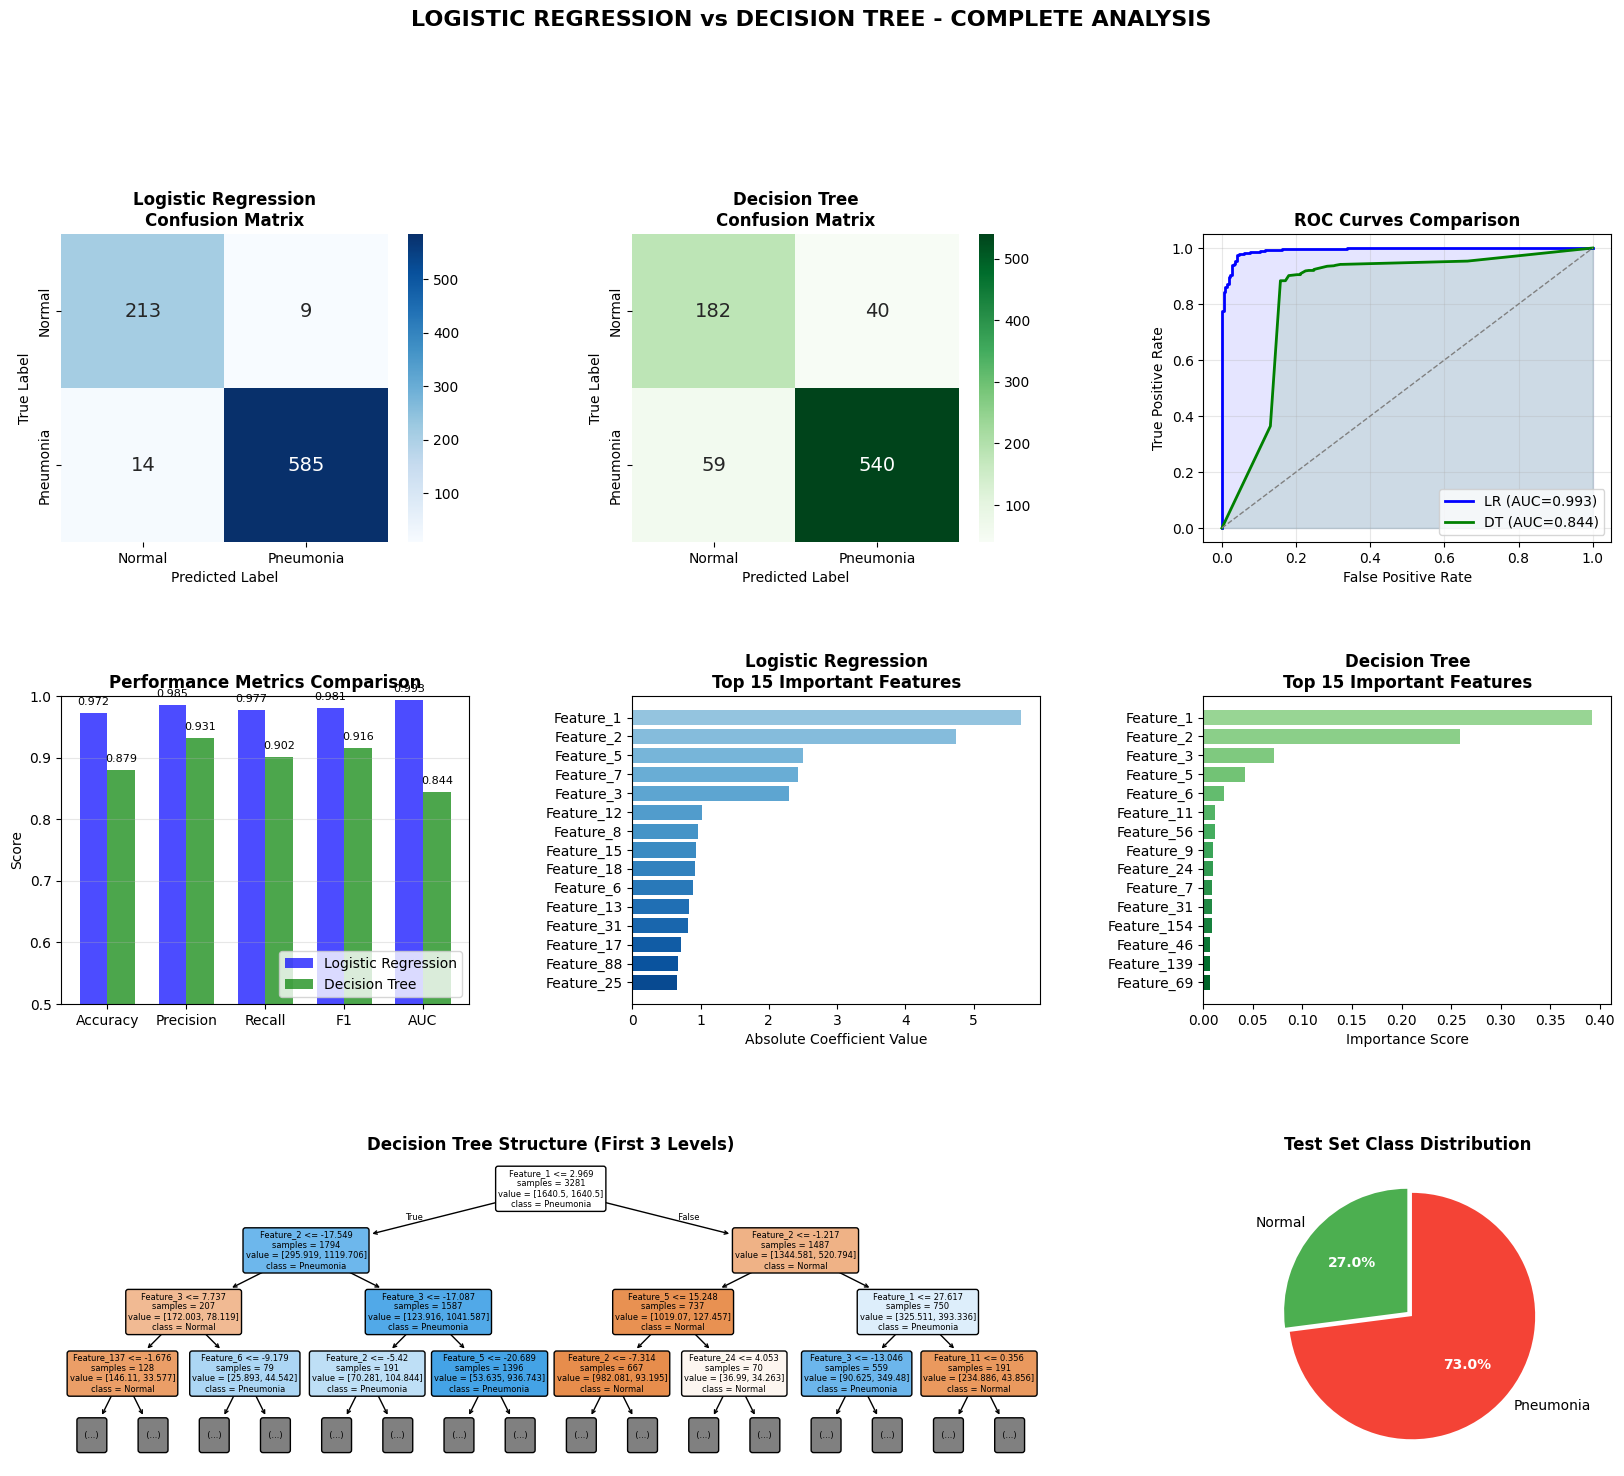


📝 MODEL CHARACTERISTICS

🔵 LOGISTIC REGRESSION:
   ✅ Fast training and prediction
   ✅ Provides probability estimates
   ✅ Works well with scaled/normalized features
   ✅ Interpretable coefficients (feature importance)
   ✅ Good for linearly separable data
   ❌ Assumes linear relationship between features and log-odds
   ❌ Sensitive to outliers
   ❌ Requires feature scaling
   ❌ May underperform on highly non-linear data

🟢 DECISION TREE:
   ✅ No feature scaling required
   ✅ Handles non-linear relationships naturally
   ✅ Highly interpretable (visual tree structure)
   ✅ Built-in feature importance
   ✅ Handles both numerical and categorical data
   ❌ Prone to overfitting without pruning
   ❌ Unstable (small data changes can create different trees)
   ❌ Can create biased trees with imbalanced data
   ❌ Greedy algorithm (may not find global optimum)

🏆 FINAL VERDICT

Based on Test Set Performance:

   📊 Best Accuracy:  Logistic Regression (97.2%)
   🎯 Best Recall:    Logistic Regressi

In [2]:
# ============================================
# LOGISTIC REGRESSION vs DECISION TREE
# PNEUMONIA DETECTION - COMPLETE CODE
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (classification_report, confusion_matrix,
                           accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("LOGISTIC REGRESSION vs DECISION TREE - PNEUMONIA DETECTION")
print("="*70)

# ============================================
# 1. LOAD THE CSV DATASET
# ============================================

csv_path = '/kaggle/input/datasets/mtishakil/chest-x-ray-feature-extracted-dataset-for-ml/Chest X-Ray Feature Extracted Dataset for ML.csv'

print(f"\n📂 Loading dataset...")
df = pd.read_csv(csv_path)
print(f"✅ Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

print(f"\n📋 First 5 rows:")
print(df.head())

print(f"\n📊 Class Distribution:")
print(df['Class'].value_counts())
print(f"   Normal:     {len(df[df['Label']==0])}")
print(f"   Pneumonia:  {len(df[df['Label']==1])}")

# ============================================
# 2. PREPARE DATA
# ============================================

print("\n" + "="*70)
print("DATA PREPARATION")
print("="*70)

X = df.drop(['Image_Name', 'Label', 'Class'], axis=1)
y = df['Label']

print(f"\n✅ Features: {X.shape[1]} columns")
print(f"✅ Target: {len(y)} samples")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\n✅ Training: {len(X_train)} samples")
print(f"   Normal: {np.sum(y_train==0)}, Pneumonia: {np.sum(y_train==1)}")
print(f"✅ Testing:  {len(X_test)} samples")
print(f"   Normal: {np.sum(y_test==0)}, Pneumonia: {np.sum(y_test==1)}")

# Scale features (needed for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"\n✅ Features scaled for Logistic Regression")

# ============================================
# 3. TRAIN LOGISTIC REGRESSION
# ============================================

print("\n" + "="*70)
print("1️⃣  LOGISTIC REGRESSION")
print("="*70)

lr_model = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

print("⏳ Training Logistic Regression...")
lr_model.fit(X_train_scaled, y_train)
print("✅ Training complete!")

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)

lr_acc = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob[:, 1])

print(f"\n📊 Logistic Regression Results:")
print(f"   Accuracy:   {lr_acc:.4f} ({lr_acc*100:.1f}%)")
print(f"   Precision:  {lr_prec:.4f} ({lr_prec*100:.1f}%)")
print(f"   Recall:     {lr_rec:.4f} ({lr_rec*100:.1f}%)")
print(f"   F1-Score:   {lr_f1:.4f} ({lr_f1*100:.1f}%)")
print(f"   AUC-ROC:    {lr_auc:.4f} ({lr_auc*100:.1f}%)")

# ============================================
# 4. TRAIN DECISION TREE
# ============================================

print("\n" + "="*70)
print("2️⃣  DECISION TREE")
print("="*70)

dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion='gini',
    class_weight='balanced',
    random_state=42
)

print("⏳ Training Decision Tree...")
dt_model.fit(X_train, y_train)
print("✅ Training complete!")

dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
dt_prec = precision_score(y_test, dt_pred)
dt_rec = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_prob[:, 1])

print(f"\n📊 Decision Tree Results:")
print(f"   Accuracy:   {dt_acc:.4f} ({dt_acc*100:.1f}%)")
print(f"   Precision:  {dt_prec:.4f} ({dt_prec*100:.1f}%)")
print(f"   Recall:     {dt_rec:.4f} ({dt_rec*100:.1f}%)")
print(f"   F1-Score:   {dt_f1:.4f} ({dt_f1*100:.1f}%)")
print(f"   AUC-ROC:    {dt_auc:.4f} ({dt_auc*100:.1f}%)")

# ============================================
# 5. SIDE-BY-SIDE COMPARISON
# ============================================

print("\n" + "="*70)
print("📊 MODEL COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Logistic Regression': [lr_acc, lr_prec, lr_rec, lr_f1, lr_auc],
    'Decision Tree': [dt_acc, dt_prec, dt_rec, dt_f1, dt_auc]
})

print(f"\n{comparison_df.to_string(index=False)}")

lr_avg = (lr_acc + lr_prec + lr_rec + lr_f1 + lr_auc) / 5
dt_avg = (dt_acc + dt_prec + dt_rec + dt_f1 + dt_auc) / 5

print(f"\n🏆 Average Score:")
print(f"   Logistic Regression: {lr_avg:.4f}")
print(f"   Decision Tree:       {dt_avg:.4f}")
print(f"   Winner:              {'Logistic Regression' if lr_avg > dt_avg else 'Decision Tree'}")

# ============================================
# 6. CLASSIFICATION REPORTS
# ============================================

print("\n" + "="*70)
print("📋 DETAILED REPORTS")
print("="*70)

print(f"\n🔵 Logistic Regression:")
print(classification_report(y_test, lr_pred, target_names=['Normal', 'Pneumonia']))

print(f"\n🟢 Decision Tree:")
print(classification_report(y_test, dt_pred, target_names=['Normal', 'Pneumonia']))

# ============================================
# 7. MEDICAL METRICS
# ============================================

print("\n" + "="*70)
print("🏥 MEDICAL METRICS COMPARISON")
print("="*70)

lr_cm = confusion_matrix(y_test, lr_pred)
lr_tn, lr_fp, lr_fn, lr_tp = lr_cm.ravel()

dt_cm = confusion_matrix(y_test, dt_pred)
dt_tn, dt_fp, dt_fn, dt_tp = dt_cm.ravel()

medical_df = pd.DataFrame({
    'Metric': ['True Negatives (Correct Normal)', 'False Positives (False Alarm)', 
               'False Negatives (Missed Pneumonia)', 'True Positives (Caught Pneumonia)',
               'Sensitivity (Recall)', 'Specificity', 'PPV (Precision)', 'NPV'],
    'Logistic Regression': [
        lr_tn, lr_fp, lr_fn, lr_tp,
        f'{lr_tp/(lr_tp+lr_fn):.4f}', f'{lr_tn/(lr_tn+lr_fp):.4f}',
        f'{lr_tp/(lr_tp+lr_fp):.4f}', f'{lr_tn/(lr_tn+lr_fn):.4f}'
    ],
    'Decision Tree': [
        dt_tn, dt_fp, dt_fn, dt_tp,
        f'{dt_tp/(dt_tp+dt_fn):.4f}', f'{dt_tn/(dt_tn+dt_fp):.4f}',
        f'{dt_tp/(dt_tp+dt_fp):.4f}', f'{dt_tn/(dt_tn+dt_fn):.4f}'
    ]
})

print(f"\n{medical_df.to_string(index=False)}")

print(f"\n⚠️  Missed Pneumonia Cases (False Negatives):")
print(f"   Logistic Regression: {lr_fn} {'❌ CRITICAL!' if lr_fn > 5 else '⚠️  Acceptable'}")
print(f"   Decision Tree:       {dt_fn} {'❌ CRITICAL!' if dt_fn > 5 else '⚠️  Acceptable'}")

# ============================================
# 8. VISUALIZATIONS
# ============================================

print("\n" + "="*70)
print("📈 GENERATING VISUALIZATIONS")
print("="*70)

fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 3, hspace=0.5, wspace=0.4)

# 1. LR Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            annot_kws={'size': 14})
ax1.set_title('Logistic Regression\nConfusion Matrix', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# 2. DT Confusion Matrix
ax2 = fig.add_subplot(gs[0, 1])
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            annot_kws={'size': 14})
ax2.set_title('Decision Tree\nConfusion Matrix', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

# 3. ROC Curves Comparison
ax3 = fig.add_subplot(gs[0, 2])
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob[:, 1])
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob[:, 1])
ax3.plot(lr_fpr, lr_tpr, color='blue', lw=2, label=f'LR (AUC={lr_auc:.3f})')
ax3.plot(dt_fpr, dt_tpr, color='green', lw=2, label=f'DT (AUC={dt_auc:.3f})')
ax3.plot([0, 1], [0, 1], '--', color='gray', lw=1)
ax3.fill_between(lr_fpr, lr_tpr, alpha=0.1, color='blue')
ax3.fill_between(dt_fpr, dt_tpr, alpha=0.1, color='green')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curves Comparison', fontsize=12, fontweight='bold')
ax3.legend(loc='lower right')
ax3.grid(True, alpha=0.3)

# 4. Performance Bar Chart
ax4 = fig.add_subplot(gs[1, 0])
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
lr_scores = [lr_acc, lr_prec, lr_rec, lr_f1, lr_auc]
dt_scores = [dt_acc, dt_prec, dt_rec, dt_f1, dt_auc]
x = np.arange(len(metrics))
width = 0.35
bars1 = ax4.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='blue', alpha=0.7)
bars2 = ax4.bar(x + width/2, dt_scores, width, label='Decision Tree', color='green', alpha=0.7)
ax4.set_ylabel('Score')
ax4.set_title('Performance Metrics Comparison', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics)
ax4.legend(loc='lower right')
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim([0.5, 1.0])

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# 5. LR Top Features
ax5 = fig.add_subplot(gs[1, 1])
feature_importance_lr = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': np.abs(lr_model.coef_[0])
}).sort_values('Coefficient', ascending=False).head(15)
colors_lr = plt.cm.Blues(np.linspace(0.4, 0.9, 15))
ax5.barh(feature_importance_lr['Feature'][::-1], feature_importance_lr['Coefficient'][::-1], color=colors_lr[::-1])
ax5.set_xlabel('Absolute Coefficient Value')
ax5.set_title('Logistic Regression\nTop 15 Important Features', fontsize=12, fontweight='bold')

# 6. DT Top Features
ax6 = fig.add_subplot(gs[1, 2])
feature_importance_dt = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)
colors_dt = plt.cm.Greens(np.linspace(0.4, 0.9, 15))
ax6.barh(feature_importance_dt['Feature'][::-1], feature_importance_dt['Importance'][::-1], color=colors_dt[::-1])
ax6.set_xlabel('Importance Score')
ax6.set_title('Decision Tree\nTop 15 Important Features', fontsize=12, fontweight='bold')

# 7. Decision Tree Visualization
ax7 = fig.add_subplot(gs[2, :2])
plot_tree(dt_model, max_depth=3, feature_names=list(X.columns),
          class_names=['Normal', 'Pneumonia'], filled=True, rounded=True,
          fontsize=6, ax=ax7, impurity=False)
ax7.set_title('Decision Tree Structure (First 3 Levels)', fontsize=12, fontweight='bold')

# 8. Test Set Distribution
ax8 = fig.add_subplot(gs[2, 2])
class_counts = [np.sum(y_test==0), np.sum(y_test==1)]
wedges, texts, autotexts = ax8.pie(class_counts, labels=['Normal', 'Pneumonia'], 
                                     autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], 
                                     startangle=90, explode=(0, 0.05))
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax8.set_title('Test Set Class Distribution', fontsize=12, fontweight='bold')

plt.suptitle('LOGISTIC REGRESSION vs DECISION TREE - COMPLETE ANALYSIS', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

# ============================================
# 9. MODEL CHARACTERISTICS
# ============================================

print("\n" + "="*70)
print("📝 MODEL CHARACTERISTICS")
print("="*70)

print(f"""
🔵 LOGISTIC REGRESSION:
   ✅ Fast training and prediction
   ✅ Provides probability estimates
   ✅ Works well with scaled/normalized features
   ✅ Interpretable coefficients (feature importance)
   ✅ Good for linearly separable data
   ❌ Assumes linear relationship between features and log-odds
   ❌ Sensitive to outliers
   ❌ Requires feature scaling
   ❌ May underperform on highly non-linear data

🟢 DECISION TREE:
   ✅ No feature scaling required
   ✅ Handles non-linear relationships naturally
   ✅ Highly interpretable (visual tree structure)
   ✅ Built-in feature importance
   ✅ Handles both numerical and categorical data
   ❌ Prone to overfitting without pruning
   ❌ Unstable (small data changes can create different trees)
   ❌ Can create biased trees with imbalanced data
   ❌ Greedy algorithm (may not find global optimum)
""")

# ============================================
# 10. FINAL VERDICT
# ============================================

print("="*70)
print("🏆 FINAL VERDICT")
print("="*70)

print(f"""
Based on Test Set Performance:

   📊 Best Accuracy:  {'Logistic Regression' if lr_acc > dt_acc else 'Decision Tree'} ({max(lr_acc, dt_acc)*100:.1f}%)
   🎯 Best Recall:    {'Logistic Regression' if lr_rec > dt_rec else 'Decision Tree'} ({max(lr_rec, dt_rec)*100:.1f}%)
   🎯 Best Precision: {'Logistic Regression' if lr_prec > dt_prec else 'Decision Tree'} ({max(lr_prec, dt_prec)*100:.1f}%)
   📈 Best AUC-ROC:   {'Logistic Regression' if lr_auc > dt_auc else 'Decision Tree'} ({max(lr_auc, dt_auc):.3f})

💡 MEDICAL APPLICATION NOTE:
   For pneumonia detection, RECALL (Sensitivity) is the MOST IMPORTANT metric.
   Missing a pneumonia case (False Negative) can be life-threatening.
   The model with HIGHER RECALL should be preferred for medical screening.
   
   Current best recall: {max(lr_rec, dt_rec)*100:.1f}%
""")

print("="*70)
print("✅ LOGISTIC REGRESSION & DECISION TREE ANALYSIS COMPLETE!")
print("="*70)